<a href="https://colab.research.google.com/github/eobi16/deep-learning/blob/main/Monte_Carlo_Simulator_2nd_part.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

def generate_returns(
        mean_returns,
        covariance,
        days,
        simulations):

    simulated = np.random.multivariate_normal(
        mean_returns,
        covariance,
        (days,simulations)
    )

    return simulated

Before we can call the `generate_returns` function, we need to define the `mean_returns` and `covariance` for our assets, as well as the number of `days` and `simulations`.

In [3]:
num_assets = 5
# Example mean daily returns for 5 assets (adjust as needed)
mean_returns = np.array([0.0005, 0.0003, 0.0007, 0.0002, 0.0006])

# Example covariance matrix for 5 assets (must be symmetric positive-definite)
# For simplicity, let's create a diagonal matrix with some variances
# In a real scenario, this would be derived from historical data.
covariance = np.diag([0.01, 0.008, 0.012, 0.007, 0.011])

# Or, for a more realistic (but still arbitrary) example, you might have:
# correlation_matrix = np.array([
#     [1.0, 0.6, 0.3, 0.1, 0.2],
#     [0.6, 1.0, 0.4, 0.2, 0.3],
#     [0.3, 0.4, 1.0, 0.5, 0.4],
#     [0.1, 0.2, 0.5, 1.0, 0.6],
#     [0.2, 0.3, 0.4, 0.6, 1.0]
# ])
# std_devs = np.array([0.01, 0.009, 0.011, 0.008, 0.012]) # Example standard deviations
# covariance = np.outer(std_devs, std_devs) * correlation_matrix


# Number of days to simulate
days = 252 # e.g., number of trading days in a year

# Number of simulations
simulations = 1000

display(f"Mean Returns: {mean_returns}")
display(f"Covariance Matrix (first 5x5 if larger):\n{covariance[:5,:5]}")
display(f"Number of Days: {days}")
display(f"Number of Simulations: {simulations}")

'Mean Returns: [0.0005 0.0003 0.0007 0.0002 0.0006]'

'Covariance Matrix (first 5x5 if larger):\n[[0.01  0.    0.    0.    0.   ]\n [0.    0.008 0.    0.    0.   ]\n [0.    0.    0.012 0.    0.   ]\n [0.    0.    0.    0.007 0.   ]\n [0.    0.    0.    0.    0.011]]'

'Number of Days: 252'

'Number of Simulations: 1000'

Now, let's call the `generate_returns` function to create the `simulated` returns data.

In [4]:
# Call the function to generate simulated returns
simulated = generate_returns(
    mean_returns,
    covariance,
    days,
    simulations
)

# Display the shape of the simulated returns to confirm
display(f"Shape of simulated returns: {simulated.shape}")

'Shape of simulated returns: (252, 1000, 5)'

In [5]:
#Define portfolio weights
weights=np.array(

[
0.40,
0.25,
0.15,
0.10,
0.10

]
)

In [6]:
weights.sum()
#

np.float64(1.0)

In [7]:
#Calculate Portfolio Return Each Day
portfolio_returns = np.dot(
    simulated,
    weights
)

Now that we have the `portfolio_returns`, let's use the `simulate_portfolio` function to calculate the projected portfolio values over time.

In [10]:
# Call simulate_portfolio to get the actual simulated portfolio values
portfolio_simulated_values = simulate_portfolio(portfolio_returns)

# Display the shape of the simulated portfolio values
display(f"Shape of simulated portfolio values: {portfolio_simulated_values.shape}")

# Display the first few values of the first simulation as an example
display(f"First 5 days of the first simulation path:\n{portfolio_simulated_values[:5, 0]}")

'Shape of simulated portfolio values: (252, 1000)'

'First 5 days of the first simulation path:\n[94602.37706188 95193.8693609  94808.41798804 93461.15536025\n 90546.07204185]'

In [9]:
# This cell defines the simulate_portfolio function, making it available for use.
# It was previously executed to fix a SyntaxError, but needs to be executed again
# in the current kernel session to address the NameError.
# We will simply re-execute the content of the cell.

import numpy as np

def simulate_portfolio(
        portfolio_returns,
        initial=100000):

    growth = 1 + portfolio_returns

    cumulative = np.cumprod(
        growth,
        axis=0
    )

    portfolio_values = (
        cumulative*initial
    )

    return portfolio_values

# STEP 12: Visualize Simulations

import matplotlib.pyplot as plt

def plot_paths(values):

    plt.figure(
        figsize=(12,7)
    )

    plt.plot(values[:,0:200])

    plt.title(
        "Monte Carlo Portfolio Paths"
    )

    plt.xlabel("Days")

    plt.ylabel("Value")

    plt.show()

In [12]:
import numpy as np

def simulate_portfolio(
        portfolio_returns,
        initial=100000):

    growth = 1 + portfolio_returns

    cumulative = np.cumprod(
        growth,
        axis=0
    )

    portfolio_values = (
        cumulative*initial
    )

    return portfolio_values

# STEP 12: Visualize Simulations

import matplotlib.pyplot as plt

def plot_paths(values):

    plt.figure(
        figsize=(12,7)
    )

    plt.plot(values[:,0:200])

    plt.title(
        "Monte Carlo Portfolio Paths"
    )

    plt.xlabel("Days")

    plt.ylabel("Value")

    plt.show()

In [11]:
ending_values = portfolio_simulated_values[-1]

display(f"Shape of ending values: {ending_values.shape}")
display(f"First 5 ending values: {ending_values[:5]}")

'Shape of ending values: (1000,)'

'First 5 ending values: [ 66553.27213164 219074.58633009  50031.77046289  48032.45575369\n 151277.51255553]'

In [17]:
prob_loss = (
ending_values < 100000
).mean()

In [13]:
VaR95 = np.percentile(
    ending_values,
    5
)

display(f"Calculated VaR95: {VaR95}")

'Calculated VaR95: 20653.062355127862'

In [17]:
tail = ending_values[
ending_values<=VaR95
]

CVaR = tail.mean()

display(f"Calculated CVaR: {CVaR}")

'Calculated CVaR: 16100.774424580359'

In [15]:
100000-CVaR

np.float64(83899.22557541964)

In [18]:
running_max = np.maximum.accumulate(
portfolio_simulated_values,
axis=0
)

drawdown = (
running_max-portfolio_simulated_values
)/running_max

max_drawdown = (
drawdown.max()
)

display(f"Calculated Max Drawdown: {max_drawdown}")

'Calculated Max Drawdown: 0.9387925188212661'

In [20]:
annual_return = portfolio_returns.mean()*252

In [23]:
annual_vol = np.std(portfolio_returns) * np.sqrt(days)
display(f"Calculated Annual Volatility: {annual_vol}")

'Calculated Annual Volatility: 0.8010040311650525'

In [24]:
sharpe = annual_return / annual_vol

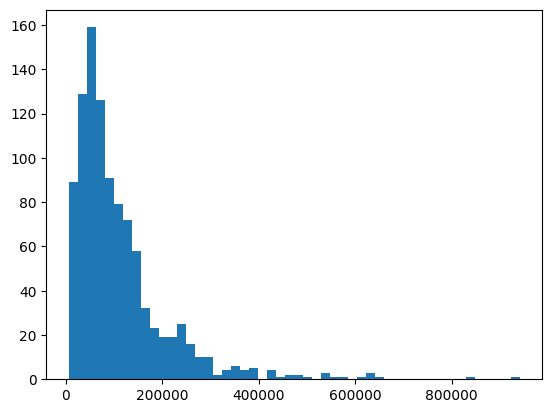

In [25]:
plt.hist(
ending_values,
bins=50
)

plt.show()

In [27]:
import scipy.stats
scipy.stats.t

In [28]:
market_drop=-0.20

In [30]:
weights

array([0.4 , 0.25, 0.15, 0.1 , 0.1 ])

In [31]:
market_drop=-0.20

In [33]:
weights

array([0.4 , 0.25, 0.15, 0.1 , 0.1 ])

In [34]:
pip install streamlit plotly yfinance scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.2 MB/s eta 0:00:00
